In [157]:
from ast import operator

import qeg_nmr_qua as qnmr

import json
from pathlib import Path
from qualang_tools.units import unit
%matplotlib widget
import matplotlib.pyplot as plt; plt.ioff() # Disable interactive mode
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.special import jn

u = unit(coerce_to_integer=True)

In [ ]:
# create base settings object for experiments
settings = qnmr.ExperimentSettings(
    n_avg=4,
    pulse_length=1.12 * u.us,
    pulse_amplitude=0.483,  # amplitude is 0.5*Vpp
    pulse_shape="square",
    pulse_rise_fall=0.0,  # 0% rise/fall time
    rotation_angle=252.3,  # degrees
    thermal_reset=4 * u.s,
    center_freq=282.1901 * u.MHz,
    offset_freq=10450 * u.Hz,
    readout_delay=20 * u.us,
    dwell_time=4 * u.us,
    readout_start=0 * u.us,
    readout_end=256 * u.us,
    save_dir=Path.home() / "Dropbox/QEG/NMR/RawData" / "mqc_expt"
)
cfg = qnmr.cfg_from_settings(settings)
expt = qnmr.Experiment3D(settings=settings, config=cfg)

rho0 = "Z" # evolve either X,Y,Z operator under DQ (& measure corresponding observable)
kick_axis = "Z" # apply X,Y,Z kick to the system, observe MQC intensities from function of kick angle
remove_echo_decay = True # For observing operator spreading |Cₘ(t)|² / Σₘ|Cₘ(t)|²
M = 2  # number of coherences
overrot = -2.75 # degrees

In [7]:
def mqc_expt(M=2, rho0="Z", kick_axis="Z", overrot=-2.75):
    # sequence time constants
    t0 = 5 * u.us
    p1 = settings.pulse_length
    thlf = (t0 - p1) / 2
    t1 = t0 - p1
    t2 = 2 * t0 - p1

    # Pine-8 sequence pattern for engineering +/- DQ
    pine8_phases = np.array([0, 0, 0, 0, 180, 180, 180, 180])
    pine8_bwd_phases = np.array([90, 90, 90, 90, 270, 270, 270, 270])
    pine8_delays = np.array([thlf, t2, t1, t2, t1, t2, t1, t2, thlf])

    kick_angles = np.arange(0, 360, 180 / M)  # degrees, from 0 to 360 in steps of 180/M

    # evolve for up to 24 periods, 0 to 24
    period_list = np.arange(0, 25, 1)

    # overrotation correction
    fc_elements = (settings.res_key, settings.helper_key)
    expt.add_frame_change(angle=overrot, elements=fc_elements)

    # rotate to evolve X, Y, or Z state operator under DQ
    if rho0 == "X": expt.add_pulse(phase=90, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=0, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # rho0, evolve under DQ
    expt.add_floquet_sequence(phases=pine8_phases, delays=pine8_delays, repetitions=period_list, loop_layer=1)

    # rotate rho(t) by variable angle about kick_axis
    if kick_axis == "X": # R_X(theta) = R_Y(-pi/2) R_Z(theta) R_Y(pi/2)
        expt.add_pulse(phase=270, element=settings.res_key)
        expt.add_delay(2.5*u.us)
        expt.add_z_rotation(angle=kick_angles, elements=(settings.res_key, settings.helper_key), loop_layer=2)
        expt.add_delay(2.5*u.us)
        expt.add_pulse(phase=90, element=settings.res_key)
    elif kick_axis == "Y": # R_Y(theta) = R_X(pi/2) R_Z(theta) R_X(-pi/2)
        expt.add_pulse(phase=0, element=settings.res_key)
        expt.add_delay(2.5*u.us)
        expt.add_z_rotation(angle=kick_angles, elements=(settings.res_key, settings.helper_key), loop_layer=2)
        expt.add_delay(2.5*u.us)
        expt.add_pulse(phase=180, element=settings.res_key)
    elif kick_axis == "Z": # R_Z(theta) is just a Z rotation
        expt.add_z_rotation(angle=kick_angles, elements=(settings.res_key, settings.helper_key), loop_layer=2)
    else: raise ValueError("Invalid kick axis choice. Must be 'X', 'Y', or 'Z'.")

    # reverse evolution via -DQ
    expt.add_floquet_sequence(phases=pine8_bwd_phases, delays=pine8_delays, repetitions=period_list, loop_layer=1)

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5*u.us)
    if rho0 == "X": expt.add_pulse(phase=270, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=180, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")

    # filter transients and measure
    expt.add_delay(1 * u.ms)
    expt.add_pulse(element=settings.res_key)

    expt.update_sweep_axis_inner(kick_angles)
    expt.update_sweep_axis_outer(period_list)
    expt.update_sweep_label_inner("Interior Z Rotation Angle (degrees)")
    expt.update_sweep_label_outer("Floquet Periods")

    expt.execute_experiment()
    # expt.remove_initial_delay(); expt.simulate_experiment()
    return expt


In [243]:
def get_mqc_intensity(re, im, periods, rotation_deg, remove_echo_decay=True):
    n_periods, n_phi = re.shape
    
    def exponent(x, tau, beta): return (-(x/tau)**beta)
    popt, pcov = curve_fit(exponent, periods, np.log(re[:, 0]/re[0,0]))
    decayfit = np.exp(exponent(periods, *popt))

    if remove_echo_decay: # normalize to φ=0 to remove echo decay envelope and observe operator spreading
        # signal = re / decayfit[:, np.newaxis] * re[0,0]
        signal = re / re[:, 0][:, np.newaxis]
        
    else: # preserve echo decay envelope, observe MQC intensities more quantitatively
        signal = re / re[0,0]

    # FFT over φ to extract MQC intensities
    rotation_rad = np.deg2rad(rotation_deg)
    dphi = np.mean(np.diff(rotation_rad))
    mqc = np.fft.fft(signal, axis=1) / n_phi
    mqc = np.fft.fftshift(mqc, axes=1)
    mqc_intensity = np.abs(mqc)
    coherence_orders = np.fft.fftshift(np.fft.fftfreq(n_phi, d=dphi/(2*np.pi))) # Frequency axis (coherence order)

    # account for the fact that we sample [0,360)
    idx_min = np.argmin(coherence_orders)  # Duplicate minimum coherence at max + 1
    coherence_orders = np.append(coherence_orders, np.max(coherence_orders) + 1)
    mqc_intensity = np.column_stack([mqc_intensity[:, idx_min]/2, mqc_intensity[:, idx_min+1:], mqc_intensity[:, idx_min]/2])

    return mqc_intensity, coherence_orders

In [ ]:
zz_expt = mqc_expt(M=2, rho0="Z", kick_axis="Z", overrot=-2.75)

-1.577209253448028 1.2804903254602151 1.98067460756432 0.6369884654102113 0.5127584697081227 -1.2730396989294608 -0.0024333796625347483
6.3479786072258815 0.8120444731849005
-0.015909677745795586 0.7611300313508019 9990.366554505272 0.05954291287691603 0.5000000004867844 -1.7046074595575904 -0.05515658839265463
6.3479786072258815 0.8120444731849005
1.5455661734794874 1.2904455072160919 8.957107992669664 0.2801716685067284 1.187955849102811 -1.1938628923425256 0.013948219858071651
6.3479786072258815 0.8120444731849005
-0.015909677745795586 0.7611300313508019 9990.366554505272 0.05954291287691603 0.5000000004867844 -1.7046074595575904 -0.05515658839265463
6.3479786072258815 0.8120444731849005
-1.577209253448028 1.2804903254602151 1.98067460756432 0.6369884654102113 0.5127584697081227 -1.2730396989294608 -0.0024333796625347483
6.3479786072258815 0.8120444731849005


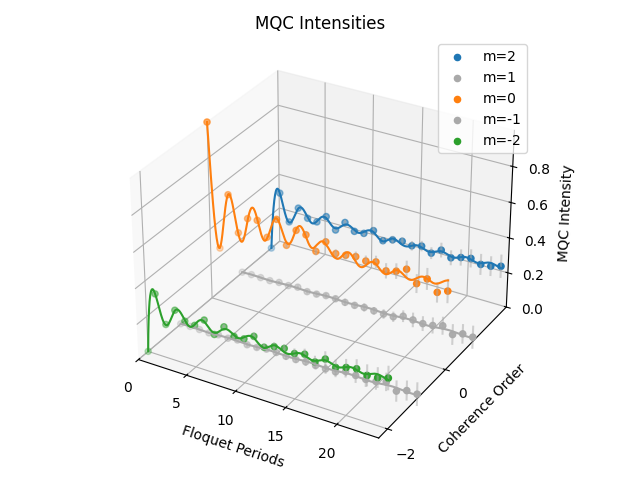

In [262]:
data_path = settings.save_dir / "experiment_0011/data.json"

if data_path is not None: 
    with open(data_path, "r") as f:
        data_dict = json.load(f) 
elif expt is not None:
    data_dict = expt.data
else: raise ValueError("Must provide either data_path or expt for analysis.")

re = np.array(data_dict["I_data"]) * 1e6
im = np.array(data_dict["Q_data"]) * 1e6
periods = np.array(data_dict["sweep_axis_outer"])
rotation_deg = np.array(data_dict["sweep_axis_inner"])
re = re[:, :, 0]  # Plot first point of FID for each period & rotation
n_periods, n_phi = re.shape

# error bars from standard deviation of im tail
n_tail = min(20, im.shape[2])
noise_floor = np.std(im[:, :, -n_tail:], axis=2)  # shape (period, phi)
std = np.mean(noise_floor, axis=1)  # shape (period,)
std_mqc = std[:, None] / np.sqrt(n_phi) # Propagate noise to MQC intensities (magnitude of FFT)
std_mqc = std_mqc / re[:, 0][:, np.newaxis] #remove echo_decay

mqc_intensity, coherence_orders = get_mqc_intensity(re, im, periods, rotation_deg, True)
mqc_decayless, coherence_orders = get_mqc_intensity(re, im, periods, rotation_deg, False)

# second moment
allowed = np.isin(coherence_orders, [0, -2, 2])
I_sel = mqc_intensity[:, allowed]
m_sel = coherence_orders[allowed]
m2_restricted = np.sum((m_sel**2) * I_sel, axis=1) / np.sum(I_sel, axis=1)

# 3D Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# render MQC intensity of each order back to front
sort_idx = np.argsort(coherence_orders)[::-1]
for j in sort_idx:
    # gray out lines where MQC intensity < 3σ stddev to de-emphasize noise floor
    if np.mean(mqc_intensity[:-10, j] / (std_mqc[10:, 0])) < 3 :
        color = 'darkgray'
    else: color = None

        # Fit the signal to the Bessel^2 function
    if j is not None:
        def damped_bessel2(x, A, k, tau, b, beta, x0, c):
            return (A * (jn(0, k * x - x0))**2 + b) * np.exp(-(x / tau)**beta) + c
        if coherence_orders[j] == 0:
            popt, pcov = curve_fit(damped_bessel2, periods, mqc_decayless[:,j], bounds=([-2, 0, 0.0, 0, 0.5, -2, -1], [2, 1.5, 9999, 2, 2, 2, 1]) )
        else:
            popt, pcov = curve_fit(damped_bessel2, periods, mqc_decayless[:,j], bounds=([-5, 0, 0.0, 0, 0.5, -2, -1], [0, 1.5, 9999, 2, 2, 2, 1]) )
        x_fit = np.linspace(min(periods), max(periods), 500)
        y_fit = damped_bessel2(x_fit, *popt)
        print(*popt)

        # Account for decay
        def exponent(x, tau, beta): return (-(x/tau)**beta)
        popt2, pcov = curve_fit(exponent, periods, np.log(re[:, 0]/re[0,0]))
        tau2_fit, beta2_fit = popt2
        decayfit = np.exp(exponent(x_fit, tau2_fit, beta2_fit))
        decayinterp = np.interp(np.linspace(0, 24, 500), np.arange(25), re[:, 0]/re[0,0])
        decay = np.where(decayinterp > 0.15, decayinterp, decayfit)

        ax.plot(x_fit, np.full_like(x_fit, coherence_orders[j]), (y_fit/decay), 
                color=color, zorder=999)
        
        print(*popt2)

    ax.scatter(periods, np.full_like(periods, coherence_orders[j]), 
        mqc_intensity[:, j], color=color, zorder=999, label =f"m={coherence_orders[j]:.0f}")
    ax.errorbar(periods, np.full_like(periods, coherence_orders[j]), mqc_intensity[:, j], 
        zerr=2*std_mqc[:, 0], fmt='none', ecolor='darkgray', alpha=0.5, zorder=1)

ax.set_xlabel("Floquet Periods"); ax.set_xlim(0, periods.max())
ax.set_ylabel("Coherence Order"); ax.set_yticks(np.arange(coherence_orders.min(), coherence_orders.max(), step=2))
ax.set_zlabel("MQC Intensity"); ax.set_zlim(0, mqc_intensity.max())

plt.title("MQC Intensities")
plt.tight_layout()
plt.legend()
plt.show()